In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/retail_store_sales.csv')

In [ ]:
df.shape

(12575, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
for col in df.columns:
    n = df[col].nunique()
    print(f'{col}: {n} unique values')

Transaction ID: 12575 unique values
Customer ID: 25 unique values
Category: 8 unique values
Item: 200 unique values
Price Per Unit: 25 unique values
Quantity: 10 unique values
Total Spent: 227 unique values
Payment Method: 3 unique values
Location: 2 unique values
Transaction Date: 1114 unique values
Discount Applied: 2 unique values


We check for fully duplicated rows and duplicates by `Transaction ID`.No true duplicates were found — every transaction is unique.

In [ ]:
df[df.duplicated()]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [ ]:
for col in ['Category', 'Payment Method', 'Location', 'Discount Applied']:
    print(f'{col}: {df[col].unique()}')

Category: ['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']
Payment Method: ['Digital Wallet' 'Credit Card' 'Cash']
Location: ['Online' 'In-store']
Discount Applied: [True False nan]


### 2. Data Cleaning`Price Per Unit`, `Quantity`, and `Total Spent` are linked by the rule **Total Spent = Price Per Unit × Quantity**. Where one value is missing but theother two are present, the missing one can be recovered arithmetically instead of dropped.

In [ ]:
before = df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum()
print("До відновлення:\n", before)

До відновлення:
 Price Per Unit    609
Quantity          604
Total Spent       604
dtype: int64


In [ ]:
mask = df['Price Per Unit'].isna() & df['Quantity'].notna() & df['Total Spent'].notna()
df.loc[mask, 'Price Per Unit'] = df.loc[mask, 'Total Spent'] / df.loc[mask, 'Quantity']
print(f'Відновлено Price Per Unit: {mask.sum()} рядків')

Відновлено Price Per Unit: 609 рядків


Rows where **both** `Quantity` and `Total Spent` are missing can't be recovered —without either, revenue can't be reconstructed. These rows are dropped as they hold noanalytical value for revenue-based analysis.

In [ ]:
both_missing = df['Quantity'].isna() & df['Total Spent'].isna()
df[both_missing][['Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent']].head()

,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent
7,CUST_21,Furniture,NaN,33.5,NaN,NaN
15,CUST_14,Beverages,NaN,24.5,NaN,NaN
19,CUST_01,Furniture,NaN,35.0,NaN,NaN
25,CUST_05,Furniture,NaN,39.5,NaN,NaN
34,CUST_06,Patisserie,NaN,23.0,NaN,NaN


In [ ]:
df_clean = df[~both_missing].copy()

Convert `Transaction Date` to datetime and `Discount Applied` to a nullable boolean.`BooleanDtype` is used (not plain `bool`) to preserve missing values, which represent"unknown" rather than "no discount".

In [ ]:
df['Transaction Date'].dtype

dtype('O')

In [ ]:
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'])

In [ ]:
df_clean['Discount Applied'].dtype

dtype('O')

In [ ]:
df_clean['Discount Applied'] = df_clean['Discount Applied'].astype(pd.BooleanDtype())

In [ ]:
df_clean.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,<NA>
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,20.0,10.0,200.0,Credit Card,Online,2023-11-30,<NA>
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False
10,TXN_8776416,CUST_22,Butchers,Item_3_BUT,8.0,9.0,72.0,Cash,In-store,2024-12-14,True


### 3. Univariate AnalysisDistribution of individual variables — categories, and descriptive statistics of numeric columns.

In [ ]:
df_clean['Category'].value_counts()

,count
Category,
Furniture,1525
Electric household essentials,1516
Milk Products,1513
Food,1507
Butchers,1496
Beverages,1496
Computers and electric accessories,1477
Patisserie,1441


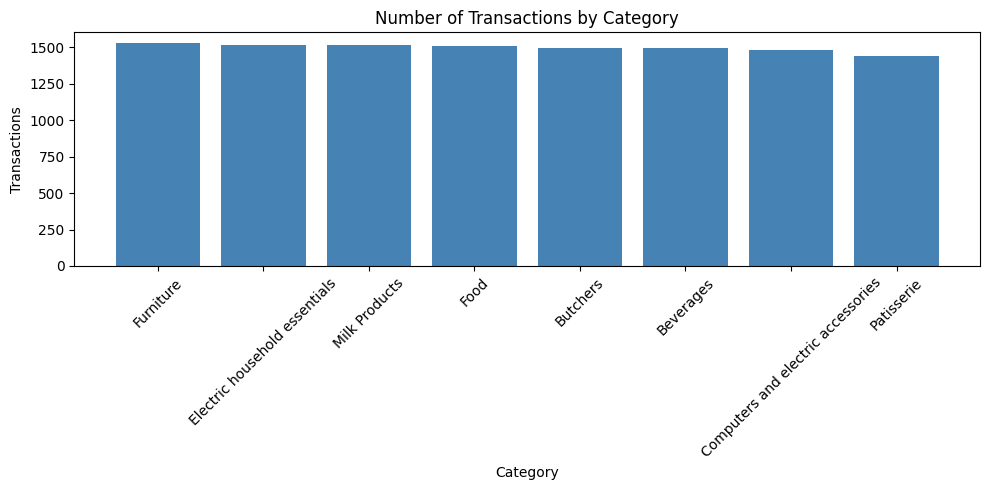

In [ ]:
category_counts = df_clean['Category'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(category_counts.index, category_counts.values, color='steelblue')
plt.title('Number of Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_clean[['Total Spent', 'Quantity', 'Price Per Unit']].describe()

,Total Spent,Quantity,Price Per Unit
count,11971.000000,11971.000000,11971.000000
mean,129.652577,5.536380,23.360872
std,94.750697,2.857883,10.741889
min,5.000000,1.000000,5.000000
25%,51.000000,3.000000,14.000000
50%,108.500000,6.000000,23.000000
75%,192.000000,8.000000,33.500000
max,410.000000,10.000000,41.000000


### 4. Bivariate AnalysisRelationships between variables — revenue by category, and cross-tabs oflocation / category against payment method.

In [ ]:
df_clean.groupby('Category').agg(
    total_revenue=('Total Spent', 'sum'),
    avg_order=('Total Spent', 'mean'),
    transaction_count=('Total Spent', 'count')
).sort_values('total_revenue', ascending=False)

,total_revenue,avg_order,transaction_count
Category,,,
Butchers,208118.0,139.116310,1496
Electric household essentials,203813.5,134.441623,1516
Beverages,197047.5,131.716243,1496
Furniture,195310.0,128.072131,1525
Food,194812.0,129.271400,1507
Computers and electric accessories,190692.5,129.107989,1477
Patisserie,182165.5,126.416031,1441
Milk Products,180112.0,119.042961,1513


In [ ]:
pd.crosstab(df_clean['Location'], df_clean['Payment Method'])

Payment Method,Cash,Credit Card,Digital Wallet
Location,,,
In-store,2032,1918,1953
Online,2071,2009,1988


In [ ]:
pd.crosstab(df_clean['Category'], df_clean['Payment Method'])

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,554,457,485
Butchers,495,528,473
Computers and electric accessories,521,490,466
Electric household essentials,518,466,532
Food,528,482,497
Furniture,509,506,510
Milk Products,497,519,497
Patisserie,481,479,481


### 5. Customer AnalysisProfiling customers — top spenders and per-customer aggregates(transaction count, total revenue, average order, first/last purchase).

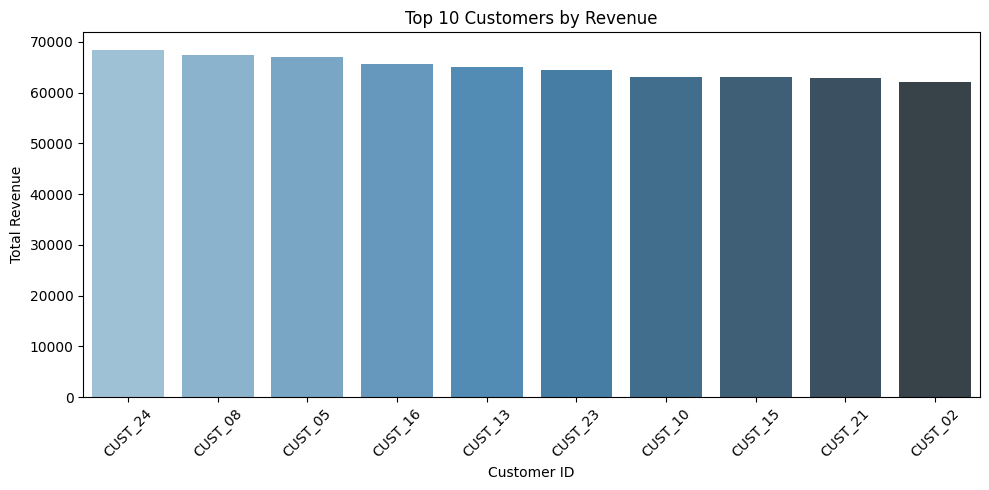

In [ ]:
customer_revenue = df_clean.groupby('Customer ID')['Total Spent'].sum().reset_index()
customer_revenue.columns = ['Customer ID', 'total_revenue']

top10 = customer_revenue.nlargest(10, 'total_revenue')

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='Customer ID', y='total_revenue',
            hue='Customer ID', palette='Blues_d')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_clean['Customer ID'].nunique()

25

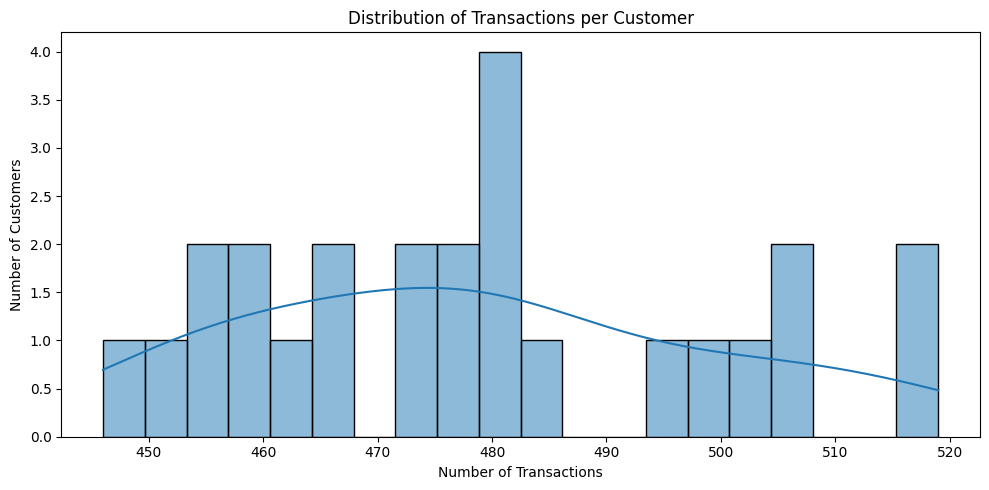

In [ ]:
transactions_per_customer = df_clean.groupby('Customer ID').size()

plt.figure(figsize=(10, 5))
sns.histplot(transactions_per_customer, bins=20, kde=True)
plt.title('Distribution of Transactions per Customer')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [ ]:
customer_stats = df_clean.groupby('Customer ID').agg(
    transaction_count=('Transaction ID', 'count'),
    total_revenue=('Total Spent', 'sum'),
    avg_order=('Total Spent', 'mean'),
    first_purchase=('Transaction Date', 'min'),
    last_purchase=('Transaction Date', 'max')
).round(2)

customer_stats

,transaction_count,total_revenue,avg_order,first_purchase,last_purchase
Customer ID,,,,,
CUST_01,485,58731.5,121.10,2022-01-01,2025-01-18
CUST_02,467,62046.5,132.86,2022-01-17,2025-01-16
CUST_03,446,60811.0,136.35,2022-01-08,2025-01-16
CUST_04,455,61767.5,135.75,2022-01-02,2025-01-18
CUST_05,516,66974.5,129.80,2022-01-03,2025-01-14
CUST_06,460,58632.5,127.46,2022-01-01,2025-01-16
CUST_07,461,60694.5,131.66,2022-01-04,2025-01-12
CUST_08,507,67351.5,132.84,2022-01-03,2025-01-17
CUST_09,498,61423.5,123.34,2022-01-03,2025-01-17


### 6. Time Series AnalysisRevenue trends over time — monthly revenue, and a month × category heatmap to surface any seasonality.

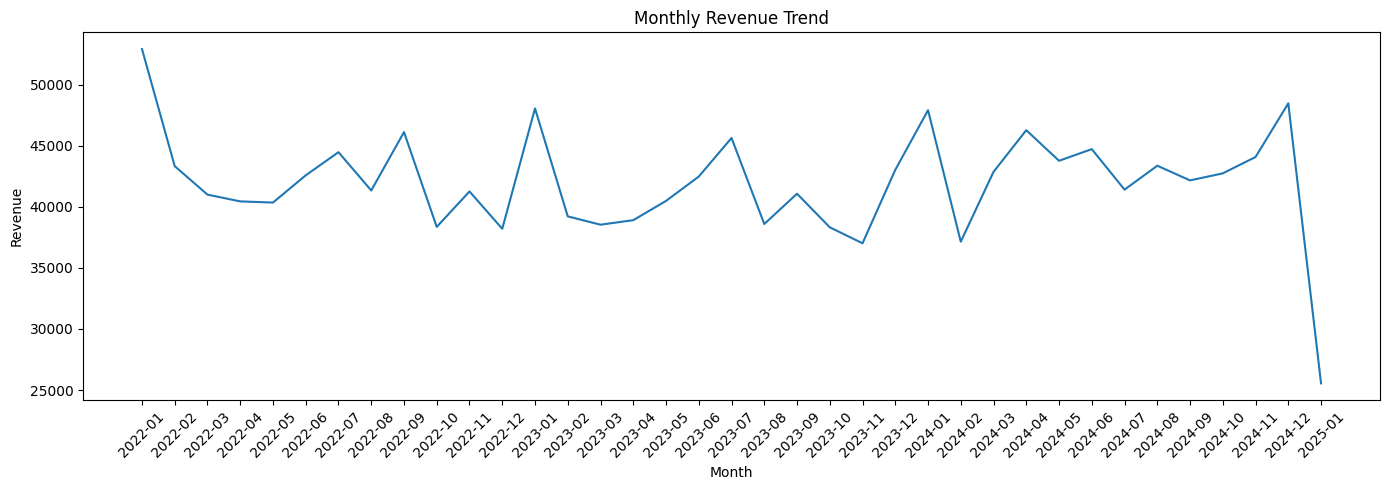

In [ ]:
monthly_revenue = df_clean.groupby(
    df_clean['Transaction Date'].dt.to_period('M')
)['Total Spent'].sum().reset_index()

monthly_revenue.columns = ['Month', 'Revenue']
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

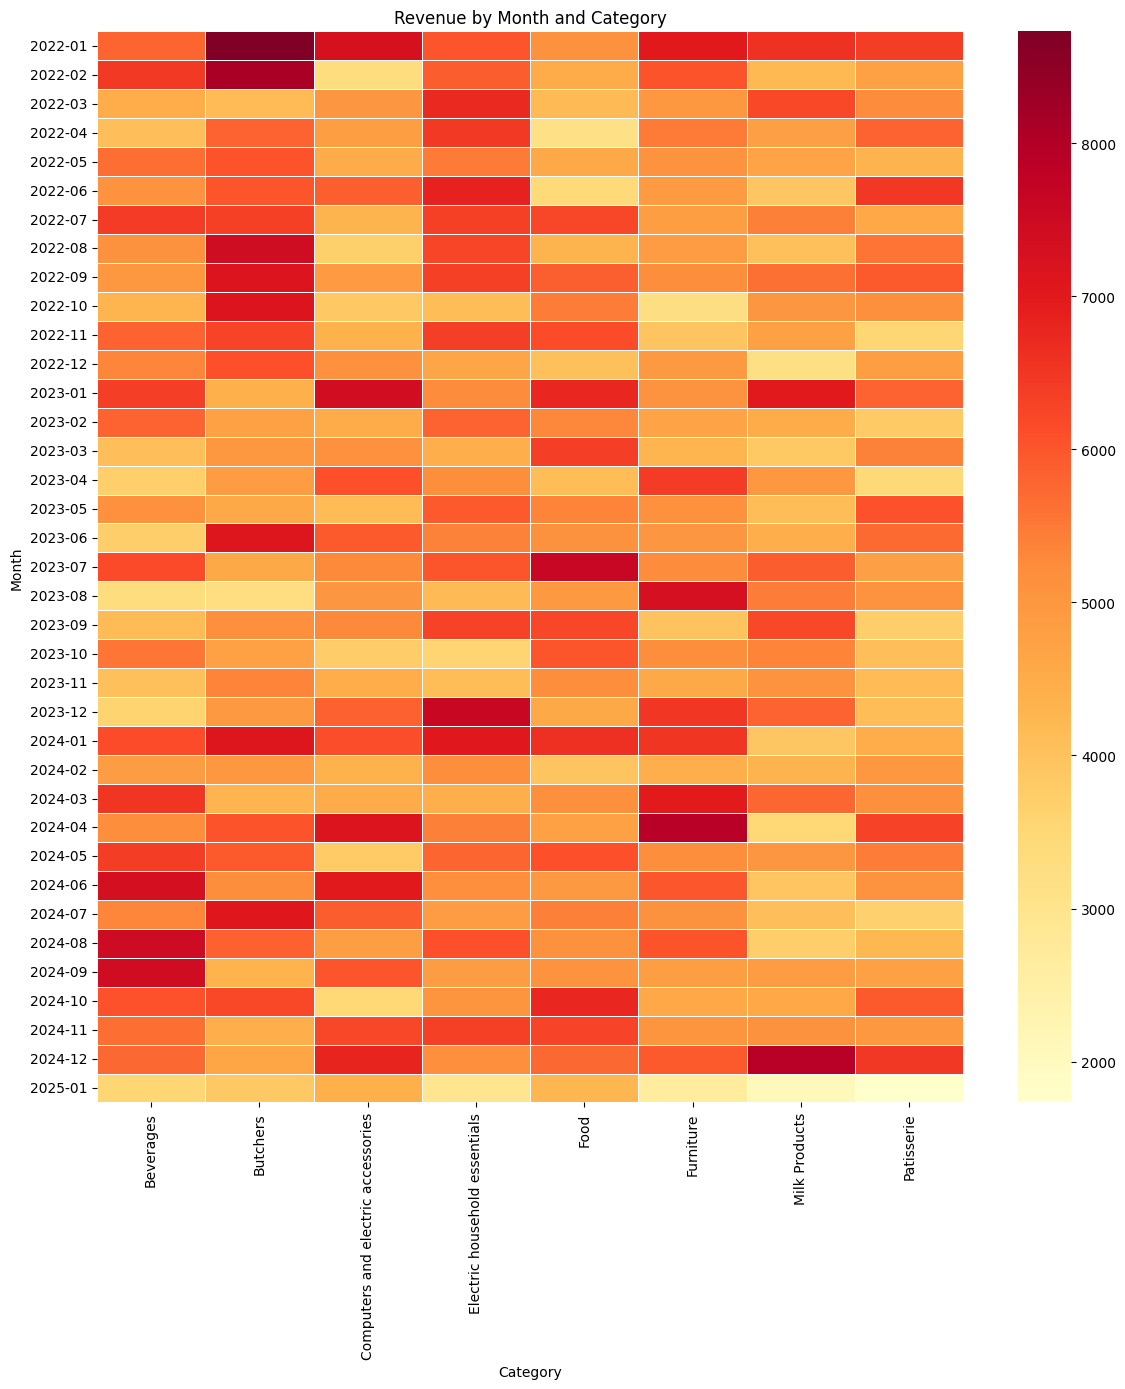

In [ ]:
df_clean['Month'] = df_clean['Transaction Date'].dt.to_period('M')

pivot = df_clean.groupby(['Month', 'Category'])['Total Spent'].sum().unstack()

plt.figure(figsize=(12, 14))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title('Revenue by Month and Category')
plt.xlabel('Category')
plt.ylabel('Month')
plt.tight_layout()
plt.show()